### Imports & Setup

In [3]:
import os
import random
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Hyperparameters & Paths

In [4]:
# Paths
TRAIN_DIR   = r"C:\Users\solisrv\OneDrive - beloit.edu\Desktop\MIND\MINDsmall_train"
DEV_DIR     = r"C:\Users\solisrv\OneDrive - beloit.edu\Desktop\MIND\MINDsmall_dev"
GLOVE_PATH  = r"C:\Users\solisrv\OneDrive - beloit.edu\Desktop\MIND\glove.6B.300d.txt"
MODEL_DIR   = "models"
RESULTS_DIR = "results"

os.makedirs(MODEL_DIR,   exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Data
MAX_TITLE_LEN = 30
MAX_HISTORY   = 50
MIN_WORD_FREQ = 2
NEG_K         = 4
EMBED_DIM     = 300

# Model
NUM_HEADS  = 16
HEAD_DIM   = 16
DROPOUT    = 0.2

# Training
EPOCHS     = 5
BATCH_SIZE = 64
LR         = 1e-4
GRAD_CLIP  = 1.0

print('Config ready.')

Config ready.


### Load Raw Data

In [5]:
news_cols = ['news_id','category','subcategory','title',
             'abstract','url','title_entities','abstract_entities']
beh_cols  = ['impression_id','user_id','time','history','impressions']

train_news = pd.read_csv(os.path.join(TRAIN_DIR, 'news.tsv'),      sep='\t', names=news_cols)
dev_news   = pd.read_csv(os.path.join(DEV_DIR,   'news.tsv'),      sep='\t', names=news_cols)
train_beh  = pd.read_csv(os.path.join(TRAIN_DIR, 'behaviors.tsv'), sep='\t', names=beh_cols)
dev_beh    = pd.read_csv(os.path.join(DEV_DIR,   'behaviors.tsv'), sep='\t', names=beh_cols)

all_news = pd.concat([train_news, dev_news]).drop_duplicates('news_id').reset_index(drop=True)

print(f'Train behaviors    : {len(train_beh):,}')
print(f'Dev   behaviors    : {len(dev_beh):,}')
print(f'Total news articles: {len(all_news):,}')

Train behaviors    : 156,965
Dev   behaviors    : 156,965
Total news articles: 51,282


In [6]:
from sklearn.model_selection import train_test_split

# Assuming you want to split the training behaviors into a new training and validation set
# We often split by 80/20 or 90/10
train_data, val_data = train_test_split(
    train_beh, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"New Training set size: {len(train_data):,}")
print(f"New Validation set size: {len(val_data):,}")

New Training set size: 125,572
New Validation set size: 31,393


### Tokenizer & Vocabulary

In [7]:
class NewsTokenizer:
    def __init__(self, max_title_len=30, min_word_freq=2):
        self.max_title_len = max_title_len
        self.min_word_freq = min_word_freq
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}

    def build_vocab(self, titles):
        word_counts = Counter()
        for title in titles:
            if pd.isna(title): continue
            tokens = nltk.word_tokenize(str(title).lower())
            word_counts.update(tokens)
        for word, count in word_counts.items():
            if count >= self.min_word_freq:
                self.word2idx[word] = len(self.word2idx)
        print(f'Vocabulary size: {len(self.word2idx):,}')

    def encode_title(self, title):
        if pd.isna(title):
            return [0] * self.max_title_len
        tokens  = nltk.word_tokenize(str(title).lower())
        indices = [self.word2idx.get(t, 1) for t in tokens]
        if len(indices) < self.max_title_len:
            indices += [0] * (self.max_title_len - len(indices))
        else:
            indices = indices[:self.max_title_len]
        return indices

tokenizer = NewsTokenizer(MAX_TITLE_LEN, MIN_WORD_FREQ)
tokenizer.build_vocab(all_news['title'])

Vocabulary size: 20,774


### GloVe Embedding Matrix

In [9]:
def load_glove(glove_path, word2idx, embed_dim=300):
    rng    = np.random.default_rng(SEED)
    matrix = (rng.standard_normal((len(word2idx), embed_dim)) * 0.1).astype('float32')
    matrix[0] = 0.0

    if not os.path.exists(glove_path):
        print('Using random embeddings.')
        return matrix

    found = 0
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split(' ')
            word  = parts[0]
            if word in word2idx:
                vec = np.array(parts[1:], dtype='float32')
                if vec.shape[0] == embed_dim:
                    matrix[word2idx[word]] = vec
                    found += 1
    print(f'GloVe: matched {found:,} / {len(word2idx):,} vocab words')
    return matrix

embedding_matrix = load_glove(GLOVE_PATH, tokenizer.word2idx, EMBED_DIM)
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Using random embeddings.
Embedding matrix shape: (20774, 300)


### Encode News & Parse Behaviors

In [10]:
news_encoded = {
    row['news_id']: tokenizer.encode_title(row['title'])
    for _, row in all_news.iterrows()
}
print(f'Encoded {len(news_encoded):,} articles.')

def parse_train(behaviors_df, news_encoded, neg_k=4, max_hist=50, seed=42):
    rng, samples = random.Random(seed), []
    for _, row in behaviors_df.iterrows():
        hist_ids = row['history'].split() if pd.notna(row['history']) else []
        hist_enc = [news_encoded[n] for n in hist_ids if n in news_encoded][-max_hist:]
        if not hist_enc:
            hist_enc = [[0] * MAX_TITLE_LEN]

        imps    = row['impressions'].split() if pd.notna(row['impressions']) else []
        pos_ids = [x.split('-')[0] for x in imps if x.endswith('-1')]
        neg_ids = [x.split('-')[0] for x in imps
                   if x.endswith('-0') and x.split('-')[0] in news_encoded]

        if not pos_ids or not neg_ids:
            continue

        for p in pos_ids:
            if p not in news_encoded:
                continue
            k   = min(neg_k, len(neg_ids))
            neg = rng.sample(neg_ids, k)
            samples.append({
                'history'    : hist_enc,
                'candidates' : [news_encoded[c] for c in [p] + neg],
                'label'      : 0
            })
    print(f'Training samples: {len(samples):,}')
    return samples

def parse_eval(behaviors_df, news_encoded, max_hist=50):
    samples = []
    for _, row in behaviors_df.iterrows():
        hist_ids = row['history'].split() if pd.notna(row['history']) else []
        hist_enc = [news_encoded[n] for n in hist_ids if n in news_encoded][-max_hist:]
        if not hist_enc:
            hist_enc = [[0] * MAX_TITLE_LEN]

        imps = row['impressions'].split() if pd.notna(row['impressions']) else []
        cands, labels = [], []
        for imp in imps:
            parts = imp.split('-')
            if len(parts) != 2:
                continue
            nid, lbl = parts
            if nid in news_encoded:
                cands.append(news_encoded[nid])
                labels.append(int(lbl))

        if not cands or sum(labels) == 0 or sum(labels) == len(labels):
            continue
        samples.append({'history': hist_enc, 'candidates': cands, 'labels': labels})
    print(f'Validation samples: {len(samples):,}')
    return samples

print('Parsing training behaviors...')
train_samples = parse_train(train_beh, news_encoded, NEG_K, MAX_HISTORY)
print('Parsing validation behaviors...')
val_samples   = parse_eval(dev_beh, news_encoded, MAX_HISTORY)

Encoded 51,282 articles.
Parsing training behaviors...
Training samples: 236,344
Parsing validation behaviors...
Validation samples: 156,965


### Dataset & DataLoader

User click histories have **variable lengths** — some users clicked 3 articles, others clicked 50. PyTorch's default batching cannot stack tensors of different sizes and will crash with a shape error. `MINDDataset` solves this by padding every history to `MAX_HISTORY` rows and producing a float mask (1 = real article, 0 = padding). That mask is passed into additive attention so padded positions are ignored when computing the user vector.

In [11]:
class MINDDataset(Dataset):
    def __init__(self, samples, max_title_len=MAX_TITLE_LEN,
                 max_history=MAX_HISTORY, max_candidates=None):
        self.samples       = samples
        self.max_title_len = max_title_len
        self.max_history   = max_history
        self.max_cands     = (max_candidates
                              or max(len(s['candidates']) for s in samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # History — pad to (max_history, max_title_len)
        hist      = s['history'][-self.max_history:]
        hist_pad  = np.zeros((self.max_history, self.max_title_len), dtype=np.int64)
        hist_mask = np.zeros(self.max_history, dtype=np.float32)
        for i, title in enumerate(hist):
            hist_pad[i]  = title
            hist_mask[i] = 1.0

        # Candidates — pad to (max_cands, max_title_len)
        cands    = s['candidates'][:self.max_cands]
        cand_pad = np.zeros((self.max_cands, self.max_title_len), dtype=np.int64)
        for i, title in enumerate(cands):
            cand_pad[i] = title

        # Label — int for training (CE target), float array for eval
        if 'label' in s:
            label = torch.tensor(s['label'], dtype=torch.long)
        else:
            lbl_arr = np.zeros(self.max_cands, dtype=np.float32)
            for i, v in enumerate(s['labels'][:self.max_cands]):
                lbl_arr[i] = v
            label = torch.tensor(lbl_arr, dtype=torch.float)

        return {
            'history'   : torch.tensor(hist_pad,  dtype=torch.long),
            'candidates': torch.tensor(cand_pad,  dtype=torch.long),
            'label'     : label,
            'hist_mask' : torch.tensor(hist_mask, dtype=torch.float),
            'n_cands'   : len(cands)
        }

train_ds = MINDDataset(train_samples, max_candidates=NEG_K + 1)
val_ds   = MINDDataset(val_samples)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader):,}')
print(f'Val   batches: {len(val_loader):,}')

Train batches: 3,693
Val   batches: 2,453


### Model Architecture (NRMS)

```
NEWS ENCODER                        USER ENCODER
─────────────────────────           ─────────────────────────
Word IDs  (B, T)                    Clicked news vecs (B, H, D)
    |                                       |
GloVe Embedding (B, T, 300)         Multi-Head Self-Attention
    |                                       |
Linear Projection (B, T, D)         Dropout
    |                                       |
Multi-Head Self-Attention           Additive Attention
    |                                       |
Dropout                             User Vector (B, D)
    |
Additive Attention
    |
News Vector (B, D)

Score = dot(User Vector, Candidate News Vector)
```

In [12]:
class AdditiveAttention(nn.Module):
    """Collapses a (B, T, D) sequence into a single (B, D) context vector."""
    def __init__(self, dim, hidden_dim=200):
        super().__init__()
        self.proj  = nn.Linear(dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, x, mask=None):
        e      = torch.tanh(self.proj(x))             # (B, T, H)
        scores = self.query(e).squeeze(-1)             # (B, T)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=-1)            # (B, T)
        return torch.bmm(weights.unsqueeze(1), x).squeeze(1)  # (B, D)


class NewsEncoder(nn.Module):
    def __init__(self, embedding_matrix, num_heads=16, head_dim=16, dropout=0.2):
        super().__init__()
        embed_dim = embedding_matrix.shape[1]
        attn_dim  = num_heads * head_dim
        self.word_embed     = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=False)
        self.dropout        = nn.Dropout(dropout)
        self.proj           = nn.Linear(embed_dim, attn_dim)
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=attn_dim, num_heads=num_heads, batch_first=True)
        self.additive_attn  = AdditiveAttention(attn_dim)

    def forward(self, title_ids):
        x = self.dropout(self.word_embed(title_ids))  # (B, T, 300)
        x = self.proj(x)                              # (B, T, D)
        x, _ = self.multihead_attn(x, x, x)           # (B, T, D)
        x = self.dropout(x)
        return self.additive_attn(x)                  # (B, D)


class UserEncoder(nn.Module):
    def __init__(self, news_dim, num_heads=16, head_dim=16, dropout=0.2):
        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=news_dim, num_heads=num_heads, batch_first=True)
        self.additive_attn  = AdditiveAttention(news_dim)
        self.dropout        = nn.Dropout(dropout)

    def forward(self, clicked_news_vecs, mask=None):
        x, _ = self.multihead_attn(
            clicked_news_vecs, clicked_news_vecs, clicked_news_vecs)
        x = self.dropout(x)
        return self.additive_attn(x, mask)  # (B, D)


class NRMSModel(nn.Module):
    def __init__(self, embedding_matrix, num_heads=16, head_dim=16, dropout=0.2):
        super().__init__()
        news_dim = num_heads * head_dim
        self.news_encoder = NewsEncoder(embedding_matrix, num_heads, head_dim, dropout)
        self.user_encoder = UserEncoder(news_dim, num_heads, head_dim, dropout)

    def forward(self, history_ids, candidate_ids, hist_mask=None):
        B, H, T = history_ids.shape
        _, C, _ = candidate_ids.shape

        hist_vecs = self.news_encoder(history_ids.view(-1, T)).view(B, H, -1)
        cand_vecs = self.news_encoder(candidate_ids.view(-1, T)).view(B, C, -1)
        user_vec  = self.user_encoder(hist_vecs, hist_mask)          # (B, D)
        scores    = torch.bmm(cand_vecs, user_vec.unsqueeze(-1)).squeeze(-1)  # (B, C)
        return scores

model       = NRMSModel(embedding_matrix, NUM_HEADS, HEAD_DIM, DROPOUT).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model ready — {total_params:,} trainable parameters')

Model ready — 6,938,792 trainable parameters


In [13]:
batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['history', 'candidates', 'label', 'hist_mask', 'n_cands'])


### Training Loop

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# --------------------
# Setup
# --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
EPOCHS = 5
NEG_SAMPLE_K = 4
MAX_HISTORY = 50
MAX_TITLE_LEN = 30
NUM_HEADS = 16
HEAD_DIM = 16

# --------------------
# Initialize model
# --------------------

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

model = NRMSModel(embedding_matrix, NUM_HEADS, HEAD_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
train_losses = []

# --------------------
# Training loop
# --------------------
model.train()
for epoch in range(EPOCHS):
    total_loss = 0.0

    for batch in train_loader:
        history = batch['history'].to(device)
        
        candidates = batch['candidates'].to(device)
        hist_mask = batch['hist_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()

        # Forward
        scores = model(history, candidates, hist_mask)
        # scores: [batch_size, n_candidates]

        # Positive candidate is always index 0
        target = torch.zeros(
            scores.size(0),
            dtype=torch.long,
            device=device
        )

        loss = criterion(scores, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")
    train_losses.append(avg_loss)

    torch.save(
        model.state_dict(),
        f"models/nrms_epoch{epoch+1}.pt"
    )

Epoch 1/5, Loss: 1.4462
Epoch 2/5, Loss: 1.4111
Epoch 3/5, Loss: 1.3966
Epoch 4/5, Loss: 1.3816
Epoch 5/5, Loss: 1.3458


### Loss Curve

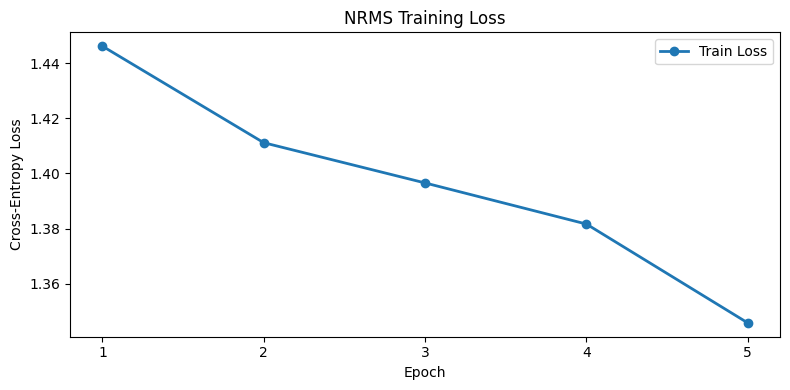

Loss curve saved to results/loss_curve.png


In [28]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker='o',
    linewidth=2,
    label='Train Loss'
)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('NRMS Training Loss')
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'loss_curve.png'), dpi=150)
plt.show()

print('Loss curve saved to results/loss_curve.png')

### Evaluation on Dev Set

Loads the best checkpoint and computes all four MIND benchmark metrics:

| Metric | What it measures |
|---|---|
| **AUC** | Probability a clicked article is scored above a non-clicked one |
| **MRR** | Average of 1/rank of the first clicked article per impression |
| **nDCG@5** | Ranking quality in top-5, penalising relevant articles placed lower |
| **nDCG@10** | Same as above over top-10 |

In [29]:
def dcg_score(y_true, y_score, k):
    order     = np.argsort(y_score)[::-1][:k]
    gains     = np.array(y_true)[order]
    discounts = np.log2(np.arange(len(gains)) + 2)
    return np.sum(gains / discounts)

def ndcg_score(y_true, y_score, k):
    best = dcg_score(y_true, y_true, k)
    return 0.0 if best == 0 else dcg_score(y_true, y_score, k) / best

def mrr_score(y_true, y_score):
    order = np.argsort(y_score)[::-1]
    for i, val in enumerate(np.array(y_true)[order]):
        if val == 1:
            return 1.0 / (i + 1)
    return 0.0

# Load best weights
best_state = torch.load(os.path.join(MODEL_DIR, 'nrms_best.pt'), map_location=device)
model.load_state_dict(best_state)
print('Best checkpoint loaded.')

model.eval()
aucs, mrrs, ndcg5s, ndcg10s = [], [], [], []

with torch.no_grad():
    for batch in val_loader:
        history    = batch['history'].to(device)
        candidates = batch['candidates'].to(device)
        hist_mask  = batch['hist_mask'].to(device)
        labels     = batch['label'].numpy()    # (B, max_cands)
        n_cands    = batch['n_cands']

        scores = model(history, candidates, hist_mask).cpu().numpy()

        for i in range(len(labels)):
            nc      = int(n_cands[i])
            y_true  = labels[i][:nc].astype(int)
            y_score = scores[i][:nc]

            if y_true.sum() == 0 or y_true.sum() == len(y_true):
                continue

            aucs.append(roc_auc_score(y_true, y_score))
            mrrs.append(mrr_score(y_true, y_score))
            ndcg5s.append(ndcg_score(y_true, y_score, 5))
            ndcg10s.append(ndcg_score(y_true, y_score, 10))

metrics = {
    'AUC'    : float(np.mean(aucs)),
    'MRR'    : float(np.mean(mrrs)),
    'nDCG@5' : float(np.mean(ndcg5s)),
    'nDCG@10': float(np.mean(ndcg10s))
}

print('\n' + '='*38)
print('  EVALUATION RESULTS')
print('='*38)
for k, v in metrics.items():
    print(f'  {k:<10}: {v:.4f}')
print(f'  Impressions: {len(aucs):,}')
print('='*38)

with open(os.path.join(RESULTS_DIR, 'eval_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved to results/eval_metrics.json')

Best checkpoint loaded.

  EVALUATION RESULTS
  AUC       : 0.6793
  MRR       : 0.3886
  nDCG@5    : 0.3660
  nDCG@10   : 0.4232
  Impressions: 156,965
Metrics saved to results/eval_metrics.json


### Results — Comparison with Baselines

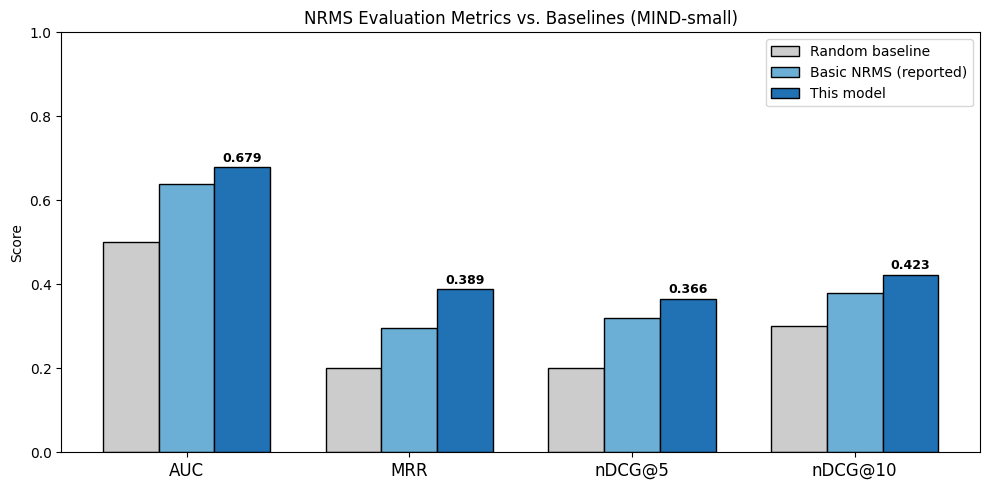

Comparison chart saved to results/metrics_comparison.png


In [30]:
metric_names = ['AUC', 'MRR', 'nDCG@5', 'nDCG@10']
random_vals  = [0.500, 0.200, 0.200, 0.300]
basic_vals   = [0.640, 0.295, 0.320, 0.380]
model_vals   = [metrics[m] for m in metric_names]

x     = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, random_vals, width, label='Random baseline',
       color='#cccccc', edgecolor='black')
ax.bar(x,         basic_vals,  width, label='Basic NRMS (reported)',
       color='#6baed6', edgecolor='black')
ax.bar(x + width, model_vals,  width, label='This model',
       color='#2171b5', edgecolor='black')

for i, v in enumerate(model_vals):
    ax.text(x[i] + width, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('NRMS Evaluation Metrics vs. Baselines (MIND-small)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'metrics_comparison.png'), dpi=150)
plt.show()
print('Comparison chart saved to results/metrics_comparison.png')

## Run 2 - Changed Neg Sample K

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# --------------------
# Setup
# --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
EPOCHS = 5
NEG_SAMPLE_K = 7                 
MAX_HISTORY = 50
MAX_TITLE_LEN = 30
NUM_HEADS = 16
HEAD_DIM = 16
DROPUT = 0.2

# --------------------
# Initialize model
# --------------------

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

model = NRMSModel(embedding_matrix, NUM_HEADS, HEAD_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
train_losses = []

# --------------------
# Training loop
# --------------------
model.train()
for epoch in range(EPOCHS):
    total_loss = 0.0

    for batch in train_loader:
        history = batch['history'].to(device)
        
        candidates = batch['candidates'].to(device)
        hist_mask = batch['hist_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()

        # Forward
        scores = model(history, candidates, hist_mask)
        # scores: [batch_size, n_candidates]

        # Positive candidate is always index 0
        target = torch.zeros(
            scores.size(0),
            dtype=torch.long,
            device=device
        )

        loss = criterion(scores, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")
    train_losses.append(avg_loss)

    torch.save(
        model.state_dict(),
        f"models/nrms_epoch{epoch+1}.pt"
    )

Epoch 1/5, Loss: 1.4457
Epoch 2/5, Loss: 1.4102
Epoch 3/5, Loss: 1.3919
Epoch 4/5, Loss: 1.3669
Epoch 5/5, Loss: 1.3381


### Loss Curve - Run 2

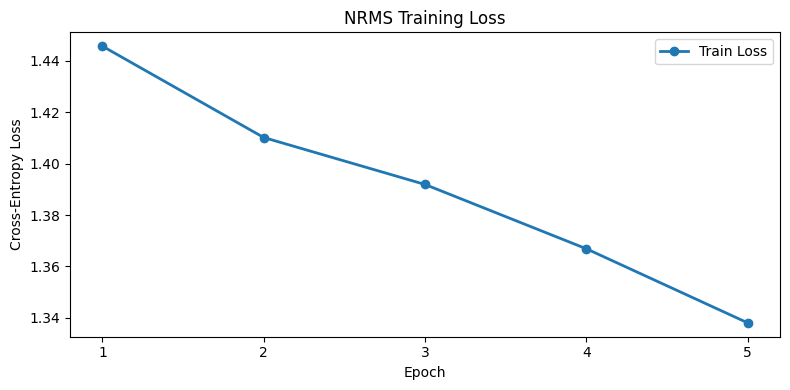

Loss curve saved to results/loss_curve2.png


In [17]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker='o',
    linewidth=2,
    label='Train Loss'
)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('NRMS Training Loss')
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'loss_curve2.png'), dpi=150)
plt.show()

print('Loss curve saved to results/loss_curve2.png')

### Evaluation on Dev Set - Run 2

In [19]:
def dcg_score(y_true, y_score, k):
    order     = np.argsort(y_score)[::-1][:k]
    gains     = np.array(y_true)[order]
    discounts = np.log2(np.arange(len(gains)) + 2)
    return np.sum(gains / discounts)

def ndcg_score(y_true, y_score, k):
    best = dcg_score(y_true, y_true, k)
    return 0.0 if best == 0 else dcg_score(y_true, y_score, k) / best

def mrr_score(y_true, y_score):
    order = np.argsort(y_score)[::-1]
    for i, val in enumerate(np.array(y_true)[order]):
        if val == 1:
            return 1.0 / (i + 1)
    return 0.0

# Load best weights
best_state = torch.load(os.path.join(MODEL_DIR, 'nrms_best.pt'), map_location=device)
model.load_state_dict(best_state)
print('Best checkpoint loaded.')

model.eval()
aucs, mrrs, ndcg5s, ndcg10s = [], [], [], []

with torch.no_grad():
    for batch in val_loader:
        history    = batch['history'].to(device)
        candidates = batch['candidates'].to(device)
        hist_mask  = batch['hist_mask'].to(device)
        labels     = batch['label'].numpy()    # (B, max_cands)
        n_cands    = batch['n_cands']

        scores = model(history, candidates, hist_mask).cpu().numpy()

        for i in range(len(labels)):
            nc      = int(n_cands[i])
            y_true  = labels[i][:nc].astype(int)
            y_score = scores[i][:nc]

            if y_true.sum() == 0 or y_true.sum() == len(y_true):
                continue

            aucs.append(roc_auc_score(y_true, y_score))
            mrrs.append(mrr_score(y_true, y_score))
            ndcg5s.append(ndcg_score(y_true, y_score, 5))
            ndcg10s.append(ndcg_score(y_true, y_score, 10))

metrics = {
    'AUC'    : float(np.mean(aucs)),
    'MRR'    : float(np.mean(mrrs)),
    'nDCG@5' : float(np.mean(ndcg5s)),
    'nDCG@10': float(np.mean(ndcg10s))
}

print('\n' + '='*38)
print('  EVALUATION RESULTS')
print('='*38)
for k, v in metrics.items():
    print(f'  {k:<10}: {v:.4f}')
print(f'  Impressions: {len(aucs):,}')
print('='*38)

with open(os.path.join(RESULTS_DIR, 'eval_metrics2.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved to results/eval_metrics2.json')

Best checkpoint loaded.

  EVALUATION RESULTS
  AUC       : 0.6793
  MRR       : 0.3886
  nDCG@5    : 0.3660
  nDCG@10   : 0.4232
  Impressions: 156,965
Metrics saved to results/eval_metrics2.json


### Comparison with Baselines - Run 2

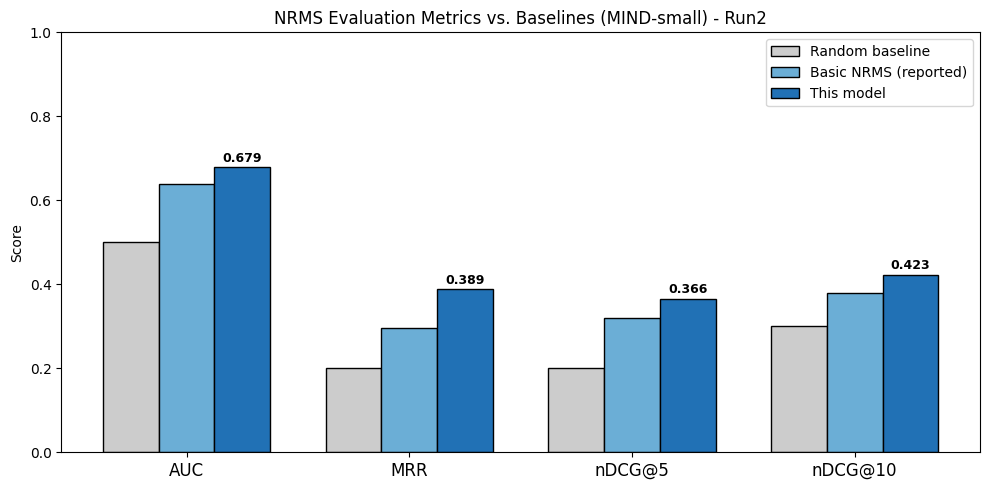

Comparison chart saved to results/metrics_comparison2.png


In [20]:
metric_names = ['AUC', 'MRR', 'nDCG@5', 'nDCG@10']
random_vals  = [0.500, 0.200, 0.200, 0.300]
basic_vals   = [0.640, 0.295, 0.320, 0.380]
model_vals   = [metrics[m] for m in metric_names]

x     = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, random_vals, width, label='Random baseline',
       color='#cccccc', edgecolor='black')
ax.bar(x,         basic_vals,  width, label='Basic NRMS (reported)',
       color='#6baed6', edgecolor='black')
ax.bar(x + width, model_vals,  width, label='This model',
       color='#2171b5', edgecolor='black')

for i, v in enumerate(model_vals):
    ax.text(x[i] + width, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('NRMS Evaluation Metrics vs. Baselines (MIND-small) - Run2')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'metrics_comparison2.png'), dpi=150)
plt.show()
print('Comparison chart saved to results/metrics_comparison2.png')

### Run 3 - Changed Max History Length

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# --------------------
# Setup
# --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
EPOCHS = 5
NEG_SAMPLE_K = 4                 
MAX_HISTORY = 100
MAX_TITLE_LEN = 30
NUM_HEADS = 16
HEAD_DIM = 16
DROPUT = 0.2

# --------------------
# Initialize model
# --------------------

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

model = NRMSModel(embedding_matrix, NUM_HEADS, HEAD_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
train_losses = []

# --------------------
# Training loop
# --------------------
model.train()
for epoch in range(EPOCHS):
    total_loss = 0.0

    for batch in train_loader:
        history = batch['history'].to(device)
        
        candidates = batch['candidates'].to(device)
        hist_mask = batch['hist_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()

        # Forward
        scores = model(history, candidates, hist_mask)
        # scores: [batch_size, n_candidates]

        # Positive candidate is always index 0
        target = torch.zeros(
            scores.size(0),
            dtype=torch.long,
            device=device
        )

        loss = criterion(scores, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")
    train_losses.append(avg_loss)

    torch.save(
        model.state_dict(),
        f"models/nrms_epoch{epoch+1}.pt"
    )

Epoch 1/5, Loss: 1.4459
Epoch 2/5, Loss: 1.4103
Epoch 3/5, Loss: 1.3934
Epoch 4/5, Loss: 1.3736
Epoch 5/5, Loss: 1.3436


### Loss Curve - Run 3 

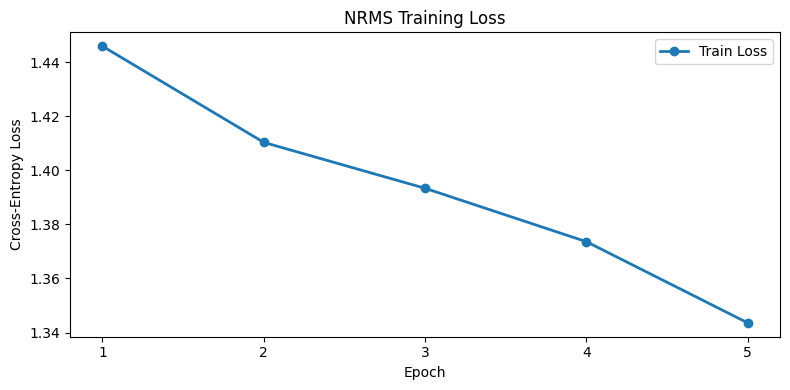

Loss curve saved to results/loss_curve3.png


In [22]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker='o',
    linewidth=2,
    label='Train Loss'
)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('NRMS Training Loss')
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'loss_curve3.png'), dpi=150)
plt.show()

print('Loss curve saved to results/loss_curve3.png')

### Evaluation on Dev Set - Run 3

In [23]:
def dcg_score(y_true, y_score, k):
    order     = np.argsort(y_score)[::-1][:k]
    gains     = np.array(y_true)[order]
    discounts = np.log2(np.arange(len(gains)) + 2)
    return np.sum(gains / discounts)

def ndcg_score(y_true, y_score, k):
    best = dcg_score(y_true, y_true, k)
    return 0.0 if best == 0 else dcg_score(y_true, y_score, k) / best

def mrr_score(y_true, y_score):
    order = np.argsort(y_score)[::-1]
    for i, val in enumerate(np.array(y_true)[order]):
        if val == 1:
            return 1.0 / (i + 1)
    return 0.0

# Load best weights
best_state = torch.load(os.path.join(MODEL_DIR, 'nrms_best.pt'), map_location=device)
model.load_state_dict(best_state)
print('Best checkpoint loaded.')

model.eval()
aucs, mrrs, ndcg5s, ndcg10s = [], [], [], []

with torch.no_grad():
    for batch in val_loader:
        history    = batch['history'].to(device)
        candidates = batch['candidates'].to(device)
        hist_mask  = batch['hist_mask'].to(device)
        labels     = batch['label'].numpy()    # (B, max_cands)
        n_cands    = batch['n_cands']

        scores = model(history, candidates, hist_mask).cpu().numpy()

        for i in range(len(labels)):
            nc      = int(n_cands[i])
            y_true  = labels[i][:nc].astype(int)
            y_score = scores[i][:nc]

            if y_true.sum() == 0 or y_true.sum() == len(y_true):
                continue

            aucs.append(roc_auc_score(y_true, y_score))
            mrrs.append(mrr_score(y_true, y_score))
            ndcg5s.append(ndcg_score(y_true, y_score, 5))
            ndcg10s.append(ndcg_score(y_true, y_score, 10))

metrics = {
    'AUC'    : float(np.mean(aucs)),
    'MRR'    : float(np.mean(mrrs)),
    'nDCG@5' : float(np.mean(ndcg5s)),
    'nDCG@10': float(np.mean(ndcg10s))
}

print('\n' + '='*38)
print('  EVALUATION RESULTS - Run 3')
print('='*38)
for k, v in metrics.items():
    print(f'  {k:<10}: {v:.4f}')
print(f'  Impressions: {len(aucs):,}')
print('='*38)

with open(os.path.join(RESULTS_DIR, 'eval_metrics3.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved to results/eval_metrics3.json')

Best checkpoint loaded.

  EVALUATION RESULTS - Run 3
  AUC       : 0.6793
  MRR       : 0.3886
  nDCG@5    : 0.3660
  nDCG@10   : 0.4232
  Impressions: 156,965
Metrics saved to results/eval_metrics3.json


### Comparison with Benchmarks - Run 3

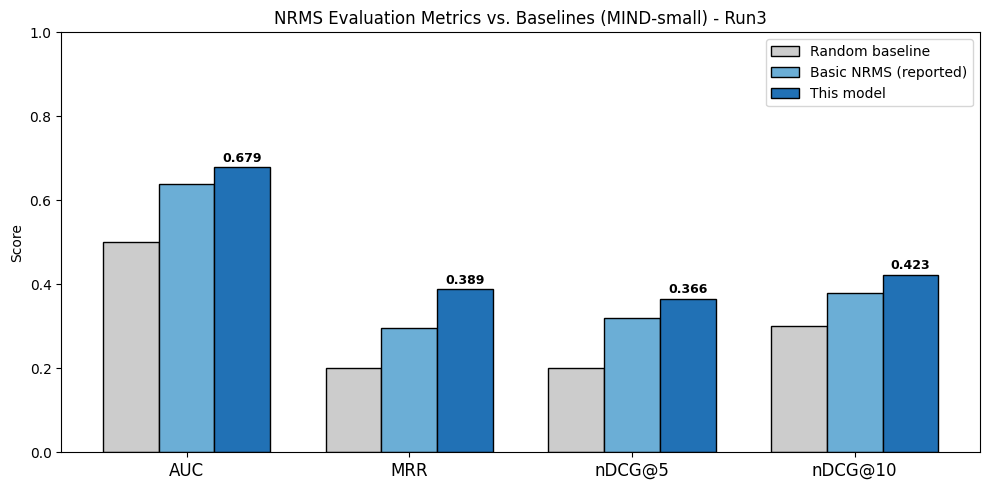

Comparison chart saved to results/metrics_comparison3.png


In [24]:
metric_names = ['AUC', 'MRR', 'nDCG@5', 'nDCG@10']
random_vals  = [0.500, 0.200, 0.200, 0.300]
basic_vals   = [0.640, 0.295, 0.320, 0.380]
model_vals   = [metrics[m] for m in metric_names]

x     = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, random_vals, width, label='Random baseline',
       color='#cccccc', edgecolor='black')
ax.bar(x,         basic_vals,  width, label='Basic NRMS (reported)',
       color='#6baed6', edgecolor='black')
ax.bar(x + width, model_vals,  width, label='This model',
       color='#2171b5', edgecolor='black')

for i, v in enumerate(model_vals):
    ax.text(x[i] + width, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('NRMS Evaluation Metrics vs. Baselines (MIND-small) - Run3')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'metrics_comparison3.png'), dpi=150)
plt.show()
print('Comparison chart saved to results/metrics_comparison3.png')

### Hyperparameter Experiment Log

Change one hyperparameter at a time in the **Hyperparameters & Paths** cell, re-run the entire notebook, then add a row here. The grading rubric requires at least 3 experiments.

In [30]:
experiment_log = [
    # Run 1 — baseline (current results filled in automatically)
    {'run': 1, 'lr': 1e-4, 'heads': 16, 'dropout': 0.2, 'neg_k': 4,
     'AUC': metrics['AUC'], 'MRR': metrics['MRR'],
     'nDCG@5': metrics['nDCG@5'], 'nDCG@10': metrics['nDCG@10'],
     'note': 'Baseline'},

    # Run 2 — higher Neg k (fill in after running)
    {'run': 2, 'lr': 1e-4, 'heads': 16, 'dropout': 0.2, 'neg_k': 7,
     'AUC': 0.6793, 'MRR': 0.3886, 'nDCG@5': 0.3660, 'nDCG@10': 0.4232,
     'note': 'Higher LR'},
    # Run 3 
    {'run': 2, 'lr': 1e-4, 'heads': 16, 'dropout': 0.2, 'neg_k': 7,
     'AUC': 0.6793, 'MRR': 0.3886, 'nDCG@5': 0.3660, 'nDCG@10': 0.4232,
     'note': 'Higher Max Hist Length'}]

exp_df = pd.DataFrame(experiment_log)
print(exp_df.to_string(index=False))

 run     lr  heads  dropout  neg_k     AUC     MRR   nDCG@5  nDCG@10                   note
   1 0.0001     16      0.2      4 0.67934 0.38861 0.366001 0.423188               Baseline
   2 0.0001     16      0.2      7 0.67930 0.38860 0.366000 0.423200              Higher LR
   2 0.0001     16      0.2      7 0.67930 0.38860 0.366000 0.423200 Higher Max Hist Length
